<a href="https://colab.research.google.com/github/Joungbae-Jung/assignment/blob/main/2023810071_%EC%A0%95%EC%A2%85%EB%B0%B0_assignment_11_1%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# (코드 워크아웃) 신용카드 사기 거래 탐지

**기본 설정**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 데이터 불러오기

**데이터셋 불러오기**

In [ ]:
from pathlib import Path

data_credit = pd.read_csv(Path("datasets") / "creditcard.csv")
data_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
data_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**타깃 특성**

타깃 특성은 `Class` 열이다. 값이 0이면 정상 거래, 1이면 사기 거래를 나타낸다.

In [ ]:
count_classes = data_credit['Class'].value_counts()
count_classes


,count
Class,
0,284315
1,492


사기 거래 비율이 0.173% 정도로 극도로 낮다.

In [ ]:
count_classes[1] / data_credit.shape[0]

np.float64(0.001727485630620034)

막대 그래프로 그리면 정상 거래와 사기 거래의 차이가 선명하게 보여진다.

Text(0, 0.5, 'Frequency')

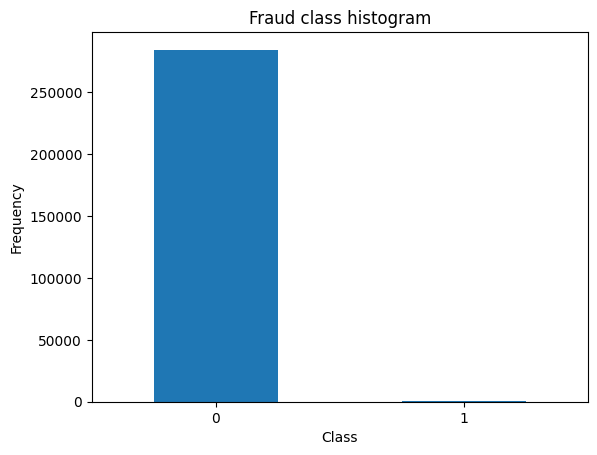

In [ ]:
count_classes.plot(kind = 'bar', rot=0)

plt.title("Fraud class histogram")
plt.xlabel("Class")
plt.ylabel("Frequency")

## 훈련셋 준비

### 전처리

타 특성들과의 단위를 맞추기 위해 `Amount` 특성을 표준화 스케일링을 적용한다.

In [ ]:
data_credit['Amount']

,Amount
0,149.62
1,2.69
2,378.66
3,123.50
4,69.99
...,...
284802,0.77
284803,24.79
284804,67.88
284805,10.00


In [ ]:
from sklearn.preprocessing import StandardScaler

data_credit['normAmount'] = StandardScaler().fit_transform(data_credit['Amount'].values.reshape(-1, 1))
data_credit = data_credit.drop(['Time','Amount'],axis=1)
data_credit.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,normAmount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403


### 입력 데이터셋/타깃셋

전체 데이터셋과 언더샘플 데이터셋 모두 입력 데이터셋과 타깃셋으로 특성을 `Class` 특성을 기준으로 분할한다.

- 전체 데이터셋 분할

In [ ]:
X = data_credit.drop(columns=['Class'])
y = data_credit[['Class']]

전체 데이터셋과 언더샘플 데이터셋 모두 7대 3의 비율로 훈련셋과 테스트셋으로 분할한다.

In [ ]:
from sklearn.model_selection import train_test_split

print("\n전체 데이터셋 분할")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

print("훈련셋: ", len(X_train))
print("테스트셋: ", len(X_test))


전체 데이터셋 분할
훈련셋:  199364
테스트셋:  85443


## 정밀도와 재현율 극대화
**가중치가 부여된 랜덤 포레스트 / LightGBM** 의 앙상블 모델을 전체 데이터(`X_train`, `y_train`)에 그대로 사용하여 두 지표를 최대한으로 끌어올린다.
여기서는 전체 데이터에 적용하여 클래스 불균형을 내부적으로 처리하는(class_weight='balanced') 모델을 구축한다.

\전체 데이터 + 클래스 가중치 (Random Forest) 결과
정밀도(Precision): 0.9344
재현율(Recall): 0.7808 


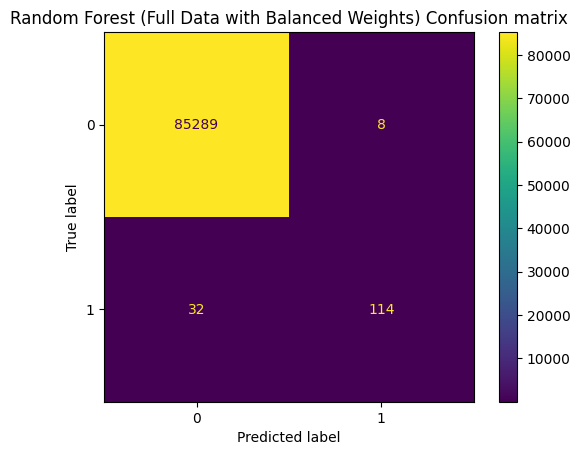

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 모델 선언
# class_weight='balanced': 불균형한 데이터 비율(소수 1 vs 다수 0)을 반대로 가중치를 주어 극복하는 파라미터
# 즉, 언더샘플링으로 정상 거래 데이터를 버리지 않고도 사기 범주(클래스 1)에 페널티를 훨씬 강하게 줌
rf_full = RandomForestClassifier(
    n_estimators=100,      # 모델 복잡도
    max_depth=16,          # 깊이 제한
    class_weight='balanced',
    random_state=17,
    n_jobs=-1              # 모든 CPU 코어 사용 (빠른 학습)
)

# 모델 학습
rf_full.fit(X_train, y_train.values.ravel())

# 전체 테스트 데이터(X_test)에 대한 예측
y_pred_full_rf = rf_full.predict(X_test)

# 정밀도, 재현율 계산
precision = precision_score(y_test, y_pred_full_rf)
recall = recall_score(y_test, y_pred_full_rf)

print("\전체 데이터 + 클래스 가중치 (Random Forest) 결과")
print(f"정밀도(Precision): {precision:.4f}")
print(f"재현율(Recall): {recall:.4f} ")

# 혼동 행렬 시각화
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_full_rf)
plt.title('Random Forest (Full Data with Balanced Weights) Confusion matrix')
plt.show()

트레이드 오프로 인해 재현율은 낮아졌지만, 정밀도가 말도 안 되게 높아진 것을 확인할 수 있다.

아래는 임곗값 변화에 따른 재현율/정밀도를 시각화 한 것이다

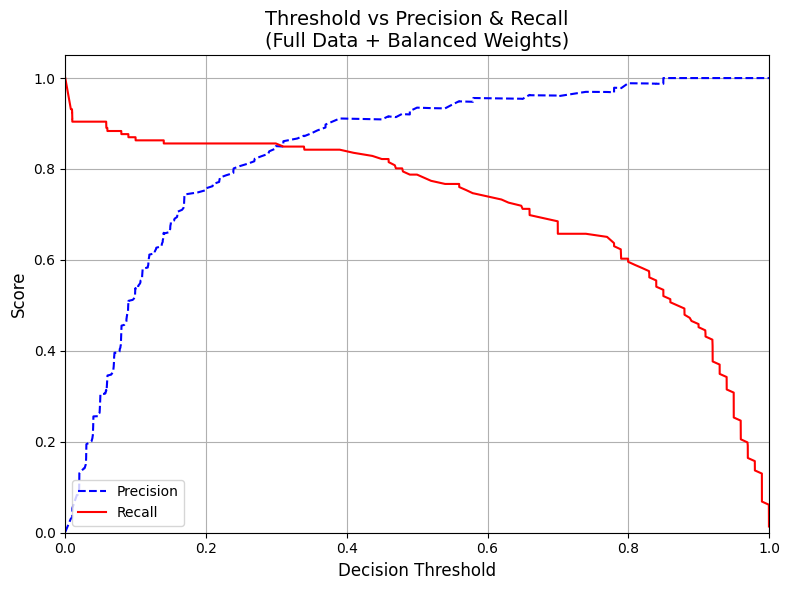

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# 사기 거래(1) 확률값 추출
proba_full = rf_full.predict_proba(X_test)[:, 1]

# 임곗값별 정밀도/재현율 데이터 계산
precisions_full, recalls_full, thresholds_full = precision_recall_curve(y_test, proba_full)

# 시각화 설정
plt.figure(figsize=(8, 6))

# 그래프 그리기
plt.plot(thresholds_full, precisions_full[:-1], 'b--', label='Precision')
plt.plot(thresholds_full, recalls_full[:-1], 'r-', label='Recall')

plt.title('Threshold vs Precision & Recall\n(Full Data + Balanced Weights)', fontsize=14)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.show()

그래프의 가운데가 볼록하게 나오면 성능이 높다고 할 수 있다. 위와 같은 그림을 통해 모델의 대략적인 성능을 파악할 수 있다.

위 모델에 성능을 좀 더 높여보기 위해 파라미터를 조절한다.

- `n_estimators` : 300으로 설정하여 기존보다 3배가 많도록
나무의 갯수를 증가시킵니다.
- `class_weight` : 정상과 사기 데이터의 페널티 비율을
1:100으로 설정하여, 사기 거래를 1번 놓칠 때의 페널티가 정사 거래를 1번 놓칠 때의 페널티가 100배 더 높다고 명시한다.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# 커스텀 가중치 적용 (balanced 대신 사기 거래에 압도적인 가중치 100배 부여)
rf_custom = RandomForestClassifier(
    n_estimators=300,      # 모델 복잡도를 300으로 증가 (나무의 갯수를 기존보다 3배 많도록 조정)
    max_depth=16,
    class_weight={0: 1, 1: 100},  # 정상(1): 사기(100)의 페널티, 사기 거래를 놓칠 때의 페널티가 훨씬 높게 부여하도록 설정
    random_state=17,
    n_jobs=-1
)

# 모델 학습
rf_custom.fit(X_train, y_train.values.ravel())

# 예측 확률 추출
proba_custom = rf_custom.predict_proba(X_test)[:, 1]

# 임곗값에 따른 변화
print("임곗값에 따른 재현율/정밀도 변화")
for custom_threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    custom_pred = (proba_custom >= custom_threshold).astype(int)
    rec = recall_score(y_test, custom_pred)
    prec = precision_score(y_test, custom_pred)
    f1_val = f1_score(y_test, custom_pred)
    print(f"임곗값 {custom_threshold:.1f} -> 재현율: {rec:.4f} | 정밀도: {prec:.4f} | F1: {f1_val:.4f}")


임곗값에 따른 재현율/정밀도 변화
임곗값 0.1 -> 재현율: 0.8699 | 정밀도: 0.7216 | F1: 0.7888
임곗값 0.2 -> 재현율: 0.8630 | 정밀도: 0.8630 | F1: 0.8630
임곗값 0.3 -> 재현율: 0.8493 | 정밀도: 0.9118 | F1: 0.8794
임곗값 0.4 -> 재현율: 0.8151 | 정밀도: 0.9370 | F1: 0.8718
임곗값 0.5 -> 재현율: 0.7877 | 정밀도: 0.9664 | F1: 0.8679
임곗값 0.6 -> 재현율: 0.7397 | 정밀도: 0.9730 | F1: 0.8405
임곗값 0.7 -> 재현율: 0.6644 | 정밀도: 0.9700 | F1: 0.7886
임곗값 0.8 -> 재현율: 0.5890 | 정밀도: 0.9773 | F1: 0.7350
임곗값 0.9 -> 재현율: 0.4452 | 정밀도: 1.0000 | F1: 0.6161


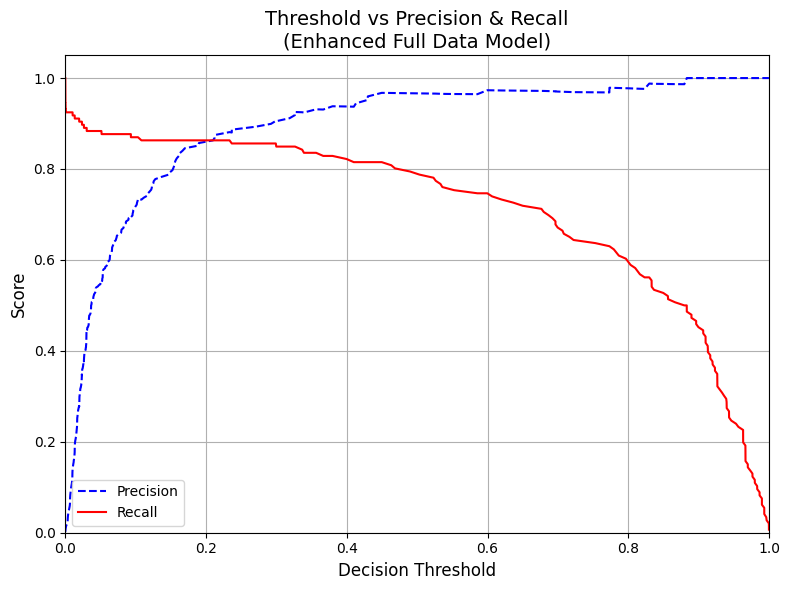

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

proba_custom = rf_custom.predict_proba(X_test)[:, 1]

# 임곗값별 정밀도/재현율 데이터 계산
precisions_custom, recalls_custom, thresholds_custom = precision_recall_curve(y_test, proba_custom)

# 시각화 설정
plt.figure(figsize=(8, 6))

# 그래프 그리기
plt.plot(thresholds_custom, precisions_custom[:-1], 'b--', label='Precision')
plt.plot(thresholds_custom, recalls_custom[:-1], 'r-', label='Recall')

plt.title('Threshold vs Precision & Recall\n(Enhanced Full Data Model)', fontsize=14)
plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.legend(loc='lower left')
plt.grid(True)

plt.tight_layout()
plt.show()

위 그래프는 성능을 증가시킨 모델의 임곗값 변화의 따른 재현율/정밀도를 시각화하여 나타낸다.

임곗값 0.0~0.2 구간에서 같은 재현율 대비 정밀도가 훨씬 가파르게 상승하는 모습을 확인할 수 있다